# 02 — Feature Engineering

Validação e análise das features construídas para o modelo de benchmark de mercado.
O modelo prediz `predicted_price` (preço de mercado), que alimenta a curva de demanda
para calcular `revenue_optimal_price` — o preço que maximiza receita esperada.

1. **Holt-Winters** sobre disponibilidade diária (preço do calendário é nulo nesse scrape)
2. **Target Encoding** de bairros — validação com CV
3. **Features de Reviews** — velocidade, recência, sinal negativo
4. **Features Geoespaciais** — distâncias a POIs e metrô
5. **Dataset Final** — overview, correlações e features de demanda

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

PROCESSED_PATH = Path('../data/processed')

## 1. Holt-Winters — Análise da Sazonalidade

In [2]:
# Holt-Winters sobre disponibilidade diária
# (preço do calendário é 100% nulo nesse scrape do Inside Airbnb para o Rio)
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pathlib import Path

PROCESSED_PATH = Path('../data/processed')

def load_calendar_avail(snapshot: str) -> pd.Series:
    """Lê Parquet do calendário e retorna taxa de disponibilidade diária (%)."""
    df = pd.read_parquet(
        PROCESSED_PATH / f'calendar_{snapshot}.parquet',
        columns=['date', 'available'],
    )
    df['is_avail'] = (df['available'] == 't').astype('int8')
    return df.groupby('date')['is_avail'].mean().mul(100).sort_index()

agg_jun = load_calendar_avail('jun2025').rename('jun')
agg_set = load_calendar_avail('set2025').rename('set')

# Combinar: setembro tem prioridade em datas sobrepostas
daily_avail = agg_jun.combine_first(agg_set)
daily_avail.update(agg_set)
daily_avail = daily_avail.asfreq('D').interpolate()

# Ajuste Holt-Winters
hw_model = ExponentialSmoothing(
    daily_avail, trend='add', seasonal='add',
    seasonal_periods=7, initialization_method='estimated'
).fit(optimized=True)

print(f'AIC: {hw_model.aic:.2f}')
print(f'alpha={hw_model.params["smoothing_level"]:.3f}  '
      f'beta={hw_model.params["smoothing_trend"]:.3f}  '
      f'gamma={hw_model.params["smoothing_seasonal"]:.3f}')
print(f'Amplitude sazonal (std): {hw_model.season.std():.2f} p.p.')

AIC: 930.54
alpha=1.000  beta=0.000  gamma=0.000
Amplitude sazonal (std): 0.62 p.p.


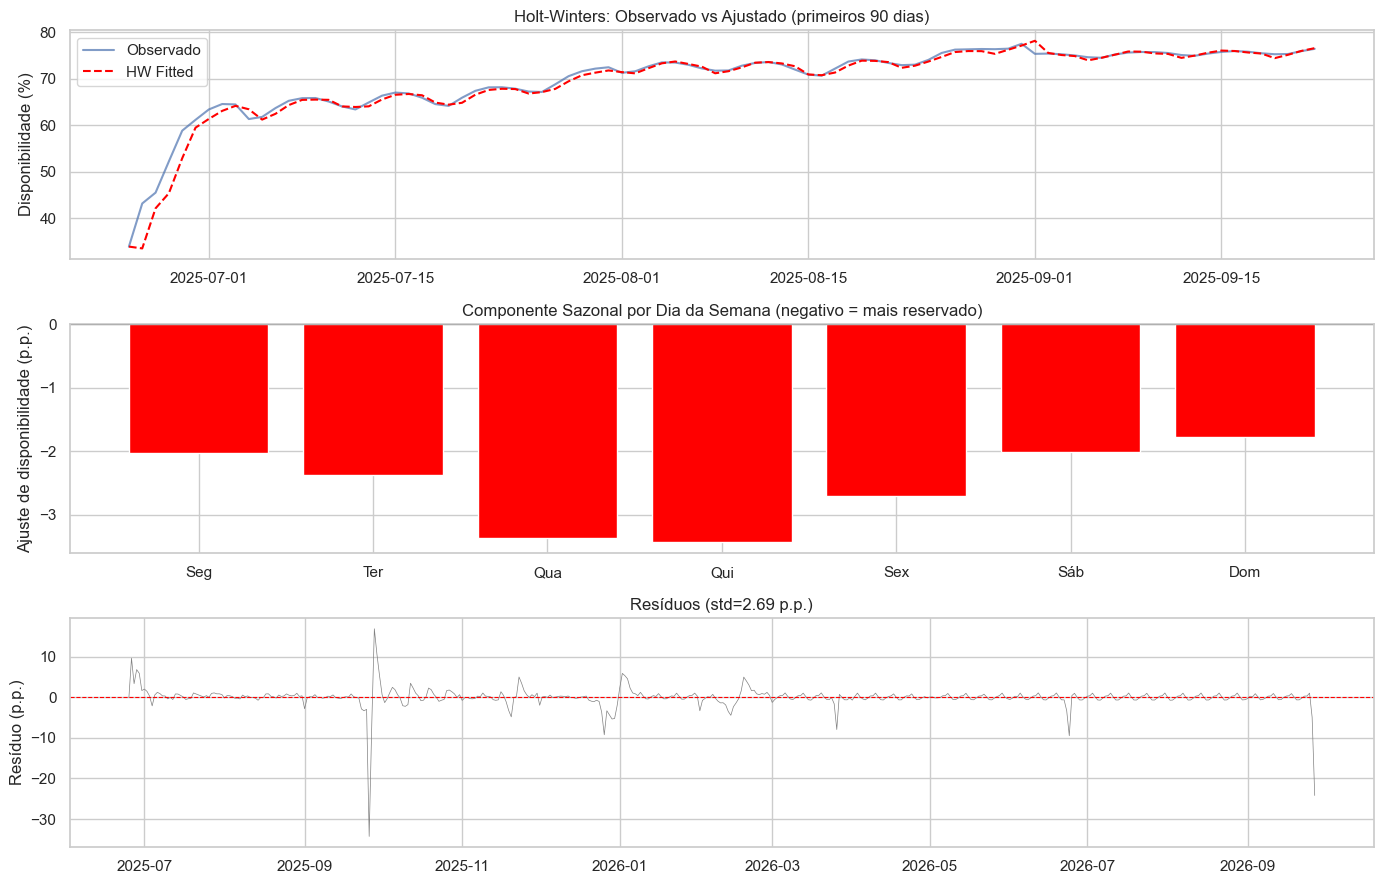

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

# Fitted vs Observed (primeiros 90 dias)
sample = daily_avail.iloc[:90]
axes[0].plot(sample.index, sample.values, label='Observado', alpha=0.7)
axes[0].plot(sample.index, hw_model.fittedvalues.iloc[:90].values,
             label='HW Fitted', linestyle='--', color='red')
axes[0].set_title('Holt-Winters: Observado vs Ajustado (primeiros 90 dias)')
axes[0].set_ylabel('Disponibilidade (%)')
axes[0].legend()

# Componente sazonal semanal
seasonal_week = hw_model.season.iloc[:7]
days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
colors = ['red' if v < 0 else 'teal' for v in seasonal_week.values]
axes[1].bar(days, seasonal_week.values, color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Componente Sazonal por Dia da Semana (negativo = mais reservado)')
axes[1].set_ylabel('Ajuste de disponibilidade (p.p.)')

# Resíduos
residuals = daily_avail - hw_model.fittedvalues
axes[2].plot(residuals.index, residuals.values, linewidth=0.5, color='gray')
axes[2].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[2].set_title(f'Resíduos (std={residuals.std():.2f} p.p.)')
axes[2].set_ylabel('Resíduo (p.p.)')

plt.tight_layout()
plt.savefig(PROCESSED_PATH / 'eda_holtwinters.png', bbox_inches='tight')
plt.show()

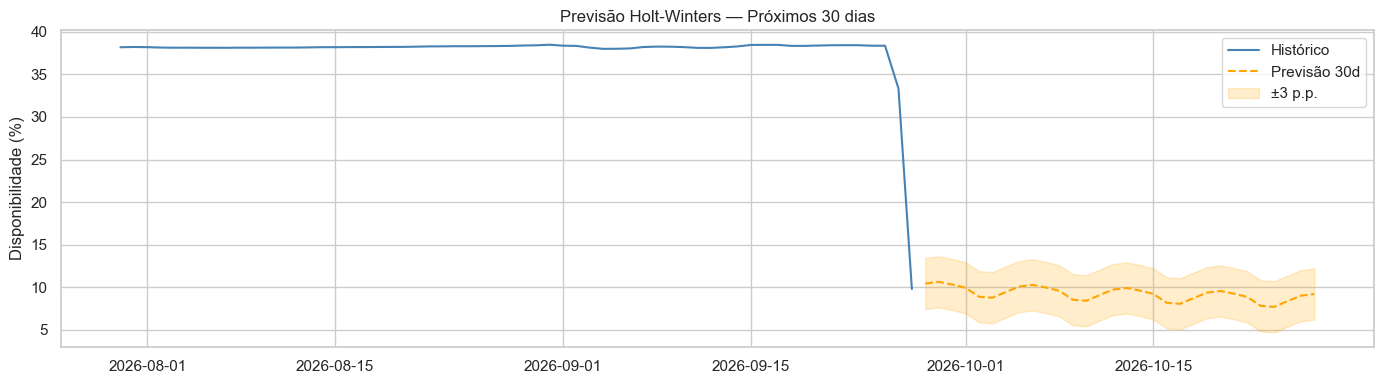

Disponibilidade prevista média: 9.2%
Min (mais concorrido): 7.7%  Max: 10.6%


In [4]:
# Previsão 30 dias à frente
forecast = hw_model.forecast(30)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_avail.iloc[-60:].index, daily_avail.iloc[-60:].values,
        label='Histórico', color='steelblue')
ax.plot(forecast.index, forecast.values,
        label='Previsão 30d', color='orange', linestyle='--')
ax.fill_between(forecast.index, forecast.values - 3, forecast.values + 3,
                alpha=0.2, color='orange', label='±3 p.p.')
ax.legend()
ax.set_title('Previsão Holt-Winters — Próximos 30 dias')
ax.set_ylabel('Disponibilidade (%)')
plt.tight_layout()
plt.show()

print(f'Disponibilidade prevista média: {forecast.mean():.1f}%')
print(f'Min (mais concorrido): {forecast.min():.1f}%  Max: {forecast.max():.1f}%')

## 2. Target Encoding — Validação

Correlação Target Encoding vs log_price (OOF): r = 0.410


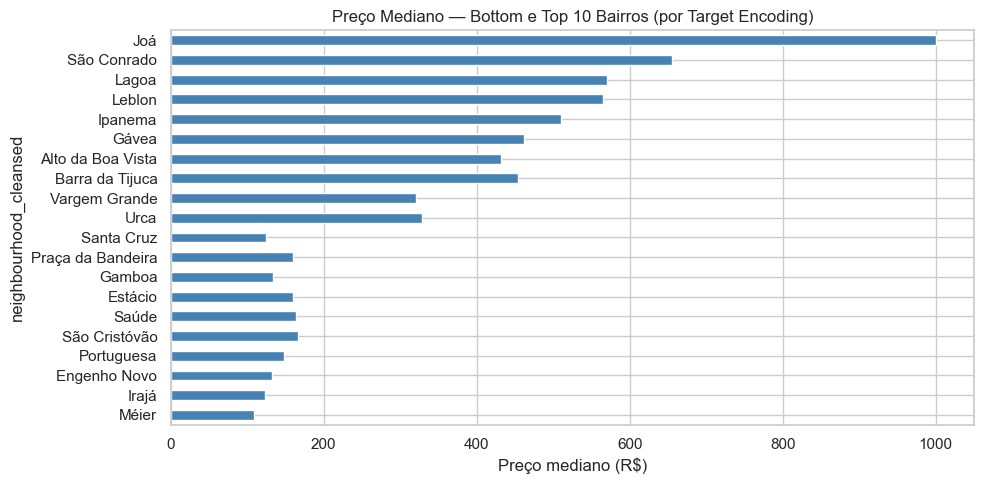

In [5]:
# Target Encoding com CV — validação anti-leakage
from category_encoders import TargetEncoder
from sklearn.model_selection import KFold

listings = pd.read_parquet(PROCESSED_PATH / 'listings_set2025.parquet',
                           columns=['id', 'price', 'neighbourhood_cleansed'])
listings['price_num'] = pd.to_numeric(
    listings['price'].astype(str).str.replace(r'[$,]', '', regex=True), errors='coerce'
)
df = listings[(listings['price_num'] >= 10) & (listings['price_num'] <= 5000)].copy()
df['log_price'] = np.log1p(df['price_num'])
df = df.dropna(subset=['neighbourhood_cleansed', 'log_price'])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
df['neighbourhood_enc'] = 0.0

for train_idx, val_idx in kf.split(df):
    enc = TargetEncoder(smoothing=10, min_samples_leaf=5)
    oof = enc.fit_transform(
        df.iloc[train_idx][['neighbourhood_cleansed']],
        df.iloc[train_idx]['log_price']
    ).squeeze()
    # transform nos val com o encoder treinado no train
    df.iloc[val_idx, df.columns.get_loc('neighbourhood_enc')] = enc.transform(
        df.iloc[val_idx][['neighbourhood_cleansed']]
    ).squeeze().values

corr = df['neighbourhood_enc'].corr(df['log_price'])
print(f'Correlação Target Encoding vs log_price (OOF): r = {corr:.3f}')

top_bot = (df.groupby('neighbourhood_cleansed')
           .agg(enc_mean=('neighbourhood_enc', 'mean'),
                price_median=('price_num', 'median'),
                count=('price_num', 'count'))
           .query('count >= 30')
           .sort_values('enc_mean'))

fig, ax = plt.subplots(figsize=(10, 5))
pd.concat([top_bot.head(10), top_bot.tail(10)])['price_median'].plot(
    kind='barh', ax=ax, color='steelblue')
ax.set_title('Preço Mediano — Bottom e Top 10 Bairros (por Target Encoding)')
ax.set_xlabel('Preço mediano (R$)')
plt.tight_layout()
plt.show()

## 3. Dataset Final — Overview

In [ ]:
# Catálogo de features por fonte
feature_sources = {
    'Tabular (numéricas)':  ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                              'minimum_nights', 'number_of_reviews', 'review_scores_rating',
                              'availability_365'],
    'Categóricas (OHE)':    ['room_type'],
    'Target Encoding':      ['neighbourhood_enc'],
    'Amenities (MLB)':      ['amenity_*  (16 amenities)'],
    'Sazonalidade (HW)':    ['hw_seasonal', 'is_weekend', 'month', 'day_of_week'],
    'Reviews':              ['review_velocity', 'days_since_last_review',
                              'total_reviews', 'neg_keyword_ratio'],
    'Geo':                  ['dist_km_praia_ipanema', 'dist_km_praia_copacabana',
                              'dist_km_cristo', 'dist_km_aeroporto_galeao',
                              'dist_km_aeroporto_sdu', 'dist_km_centro',
                              'dist_km_lapa', 'dist_km_maracana',
                              'dist_km_praia_barra_tijuca', 'dist_km_metro'],
    'Competição local':     ['comp_count', 'comp_price_p25', 'comp_price_p50',
                              'comp_price_p75', 'comp_price_rank'],
    'Imagem CLIP':          ['clip_luxury_score', 'clip_cleanliness_score',
                              'clip_emb_0..19  (PCA 20 componentes)'],
    'Imagem YOLO':          ['yolo_luxury_score', 'object_count', 'bed_count'],
}

print('=== Features por fonte ===')
total_approx = 0
for source, cols in feature_sources.items():
    count = len(cols)
    total_approx += count
    print(f'  {source:<25} {count:>3} features')
print(f'\n  TOTAL aprox.: {total_approx}+ features (antes de expansão amenities/OHE)')
print('\nNota: features de demanda (elasticidade, preço ótimo) são calculadas em')
print('demand.py via painel Jun/Set 2025 e salvas em demand_params.joblib.')

Reviews features: (33882, 5)
       review_velocity  days_since_last_review  total_reviews  n_neg_keywords  \
count        33882.000               33882.000      33882.000       33882.000   
mean             1.228                 207.060         33.284           2.300   
std              1.338                 440.777         52.650           4.019   
min              0.006                  -1.000          1.000           0.000   
25%              0.244                  16.000          4.000           0.000   
50%              0.759                  65.000         13.000           1.000   
75%              1.817                 200.000         40.000           3.000   
max             15.711                4966.000        760.000          72.000   

       neg_keyword_ratio  
count          33882.000  
mean               0.076  
std                0.134  
min                0.000  
25%                0.000  
50%                0.038  
75%                0.099  
max                1.000 

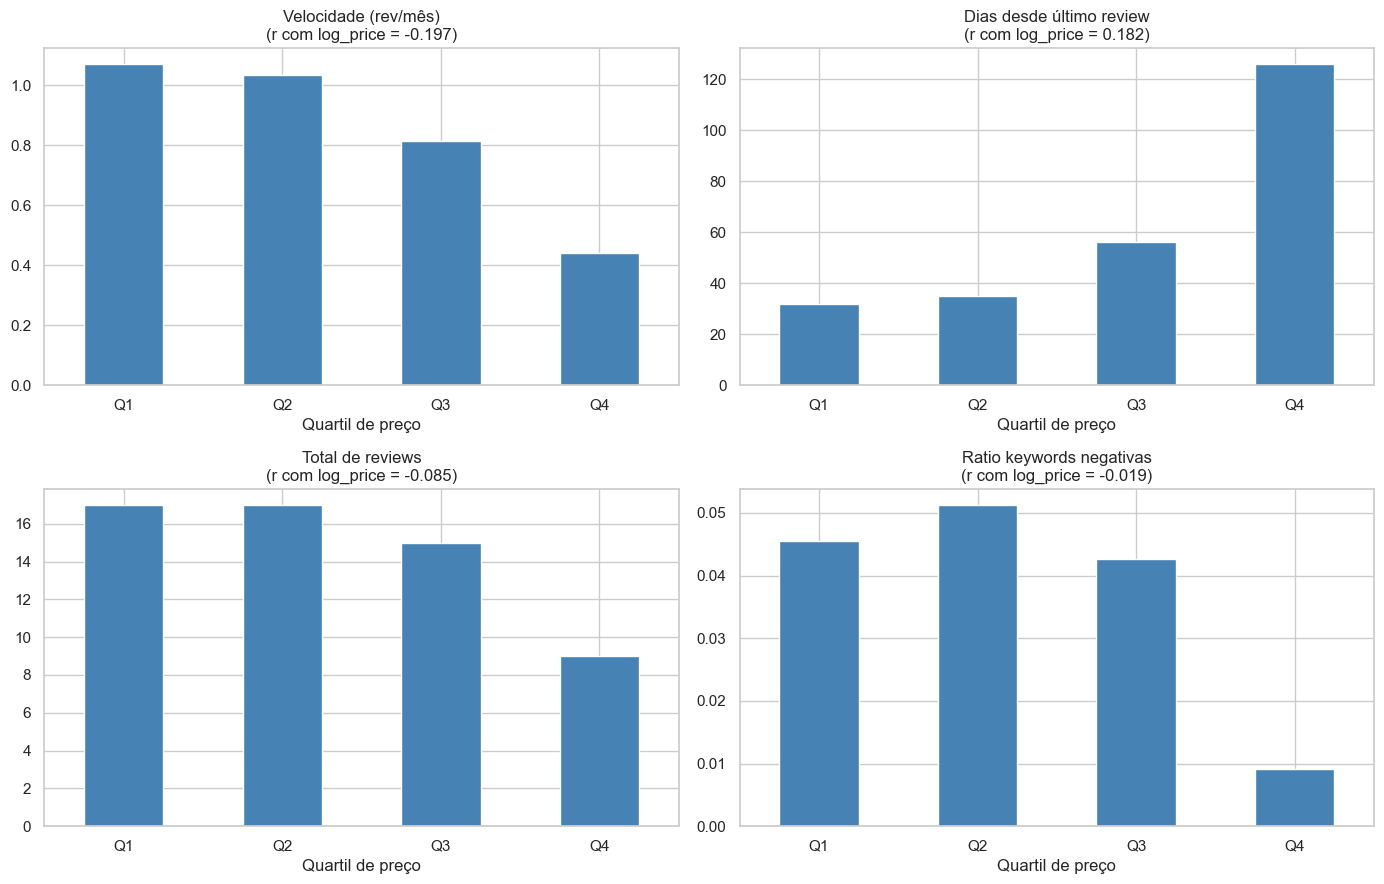

In [6]:
rev = pd.read_parquet(PROCESSED_PATH / 'reviews_features.parquet')
# df vem da célula anterior (listings com price_num e log_price calculados)
price_df = df[['id', 'price_num', 'log_price']].rename(columns={'id': 'listing_id'})
rev_price = rev.merge(price_df, left_index=True, right_on='listing_id', how='inner')

print(f'Reviews features: {rev.shape}')
print(rev.describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col, title in zip(
    axes.flat,
    ['review_velocity', 'days_since_last_review', 'total_reviews', 'neg_keyword_ratio'],
    ['Velocidade (rev/mês)', 'Dias desde último review', 'Total de reviews', 'Ratio keywords negativas'],
):
    r = rev_price[[col, 'log_price']].corr().loc[col, 'log_price']
    price_q = pd.qcut(rev_price['price_num'], 4, labels=['Q1','Q2','Q3','Q4'])
    rev_price.groupby(price_q, observed=True)[col].median().plot(
        kind='bar', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title(f'{title}\n(r com log_price = {r:.3f})')
    ax.set_xlabel('Quartil de preço')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Features Geoespaciais

Geo features: (43068, 10)


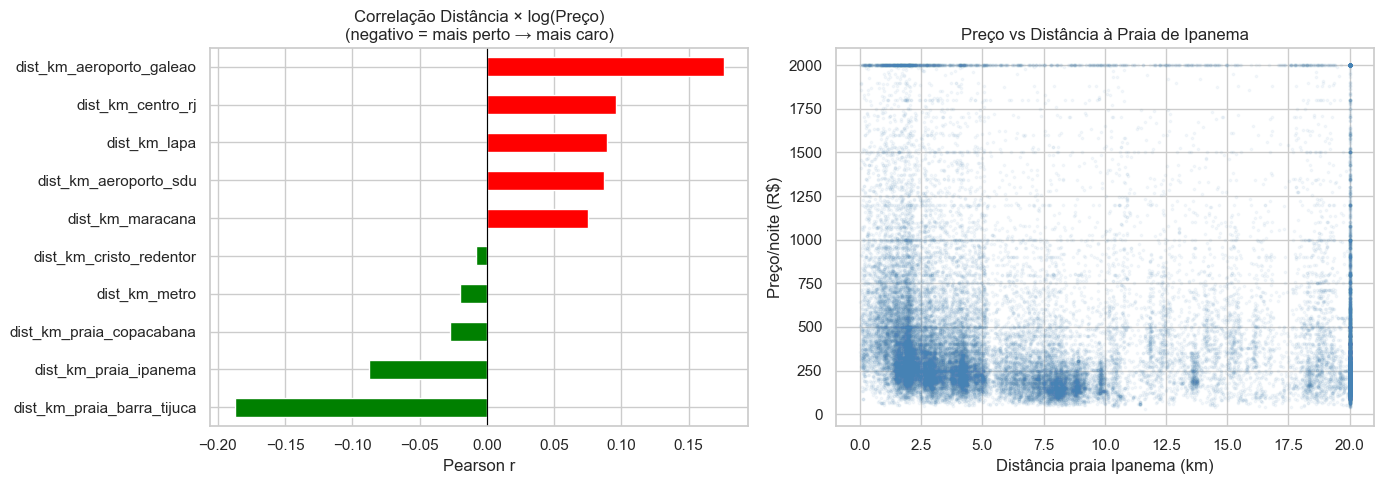


Correlações:
dist_km_praia_barra_tijuca   -0.188
dist_km_praia_ipanema        -0.087
dist_km_praia_copacabana     -0.027
dist_km_metro                -0.020
dist_km_cristo_redentor      -0.008
dist_km_maracana              0.075
dist_km_aeroporto_sdu         0.087
dist_km_lapa                  0.089
dist_km_centro_rj             0.096
dist_km_aeroporto_galeao      0.176


In [7]:
geo = pd.read_parquet(PROCESSED_PATH / 'geo_features.parquet')
geo_price = geo.merge(price_df.rename(columns={'listing_id': 'id'}),
                      left_index=True, right_on='id', how='inner')

print(f'Geo features: {geo.shape}')

dist_cols = [c for c in geo.columns if c.startswith('dist_km_')]
corr_geo = geo_price[dist_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_geo.plot(kind='barh', ax=axes[0],
              color=['green' if v < 0 else 'red' for v in corr_geo.values])
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Correlação Distância × log(Preço)\n(negativo = mais perto → mais caro)')
axes[0].set_xlabel('Pearson r')

axes[1].scatter(geo_price['dist_km_praia_ipanema'].clip(0, 20),
                geo_price['price_num'].clip(0, 2000),
                alpha=0.05, s=3, color='steelblue')
axes[1].set_xlabel('Distância praia Ipanema (km)')
axes[1].set_ylabel('Preço/noite (R$)')
axes[1].set_title('Preço vs Distância à Praia de Ipanema')

plt.tight_layout()
plt.show()

print('\nCorrelações:')
print(corr_geo.round(3).to_string())

In [ ]:
# Correlações consolidadas com log_price — geo + reviews + target encoding
# (executar após células de geo e reviews)
price_df_corr = df[['id', 'price_num', 'log_price']].rename(columns={'id': 'listing_id'})

all_feats = (
    geo_price[dist_cols + ['log_price', 'price_num', 'id']]
    .rename(columns={'id': 'listing_id'})
    .merge(
        rev_price[['review_velocity', 'days_since_last_review',
                   'total_reviews', 'neg_keyword_ratio', 'listing_id']],
        on='listing_id', how='inner'
    )
    .merge(
        df[['id', 'neighbourhood_enc']].rename(columns={'id': 'listing_id'}),
        on='listing_id', how='inner'
    )
)

num_cols = [c for c in all_feats.columns
            if c not in ('listing_id', 'price_num', 'log_price')]
corr_all = (all_feats[num_cols + ['log_price']]
            .corr()['log_price']
            .drop('log_price')
            .sort_values())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['teal' if v < 0 else 'steelblue' for v in corr_all.values]
corr_all.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlação com log(Preço) — Todas as Features Numéricas')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

print('Top 5 positivas (mais perto → mais caro, ou mais reviews → mais caro):')
print(corr_all.tail(5).round(3).to_string())
print('\nTop 5 negativas (mais longe de POI → mais barato):')
print(corr_all.head(5).round(3).to_string())

In [ ]:
# Dataset final — overview de features disponíveis para o modelo
final_path = PROCESSED_PATH / 'final_features.parquet'

if final_path.exists():
    final = pd.read_parquet(final_path)
    print(f'Shape: {final.shape}')
    print()

    categories = {
        'Numéricas base':     [c for c in final.columns if c in
                               ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                                'minimum_nights', 'maximum_nights', 'number_of_reviews',
                                'review_scores_rating', 'availability_365']],
        'One-Hot (room_type)':[c for c in final.columns if c.startswith('room_type_')],
        'Amenities (MLB)':    [c for c in final.columns if c.startswith('amenity_')],
        'Target Encoding':    [c for c in final.columns if c == 'neighbourhood_enc'],
        'Holt-Winters':       [c for c in final.columns if c.startswith('hw_') or
                               c in ['month', 'day_of_week', 'is_weekend']],
        'Reviews':            [c for c in final.columns if c in
                               ['review_velocity', 'days_since_last_review',
                                'total_reviews', 'neg_keyword_ratio', 'n_neg_keywords']],
        'Geo':                [c for c in final.columns if c.startswith('dist_km_')],
        'Competição local':   [c for c in final.columns if c.startswith('comp_')],
        'CLIP':               [c for c in final.columns if c.startswith('clip_')],
        'YOLO':               [c for c in final.columns if c.startswith(
                               ('yolo_', 'has_', 'object_', 'bed_count'))],
    }

    for cat, cols in categories.items():
        present = [c for c in cols if c in final.columns]
        if present:
            print(f'  {cat:<25} {len(present):>3} features')

    total_model = sum(1 for c in final.columns if c not in
                      ['id', 'listing_id', 'price', 'log_price', 'name',
                       'description', 'amenities', 'neighbourhood_cleansed'])
    print(f'\n  TOTAL para o modelo: ~{total_model} colunas')

    null_pct = final.isnull().sum() / len(final) * 100
    if null_pct.max() > 0:
        print('\nColunas com nulos:')
        print(null_pct[null_pct > 0].sort_values(ascending=False))
    else:
        print('\nNenhum nulo no dataset final.')
else:
    print('Dataset final nao encontrado — rode o pipeline: make feature-engineering')
    print('Colunas esperadas apos o pipeline completo:')
    print('  ~85 features cobrindo tabular, amenities, geo, reviews, competicao, sazonalidade')

## 5. Estimação de Demanda — Painel Jun/Set 2025

Os dois snapshots permitem estimar elasticidade-preço por segmento (bairro × tipo de quarto).
Para cada listing presente nos dois períodos, calculamos:
- Δlog(price): variação de preço entre jun e set
- Δlogit(occupancy): variação de ocupação implícita (1 - available_rate)

A regressão `Δlogit(occ) ~ b × Δlog(price)` estima a elasticidade `b`.
Se `b < -1` (demanda elástica), o preço ótimo que maximiza `price × occupancy` é calculado via grid search.
Se `-1 ≤ b < 0` (inelástica), a estratégia é `premium_positioning` (cobrar mais sem perder muito).

In [ ]:
import joblib
from scipy.special import expit

demand_path = PROCESSED_PATH / 'demand_params.joblib'

if not demand_path.exists():
    print('demand_params.joblib nao encontrado — rode: python -m src.features.demand')
else:
    demand_params = joblib.load(demand_path)
    print(f'Segmentos com parametros de demanda: {len(demand_params)}')

    rows = []
    for (bairro, room_type), p in demand_params.items():
        rows.append({
            'bairro': bairro,
            'room_type': room_type,
            'elasticidade_b': p.get('b'),
            'intercepto_a': p.get('a'),
            'comp_p50': p.get('comp_p50'),
            'strategy': p.get('strategy'),
            'method': p.get('method'),
            'optimal_multiplier': p.get('optimal_multiplier'),
        })
    dp = pd.DataFrame(rows).dropna(subset=['elasticidade_b'])

    print(f'\nDistribuicao de estrategias:')
    print(dp['strategy'].value_counts().to_string())
    print(f'\nMetodo de estimacao:')
    print(dp['method'].value_counts().to_string())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Distribuicao de elasticidades
    dp['elasticidade_b'].clip(-5, 0).hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].axvline(-1, color='red', linestyle='--', label='b=-1 (elastic threshold)')
    axes[0].set_title('Distribuicao de Elasticidade-Preco (b)')
    axes[0].set_xlabel('Elasticidade b')
    axes[0].legend(fontsize=8)

    # Multiplicador otimo por estrategia
    dp.groupby('strategy')['optimal_multiplier'].median().plot(
        kind='bar', ax=axes[1], color='teal', edgecolor='white')
    axes[1].axhline(1.0, color='black', lw=0.8, linestyle='--')
    axes[1].set_title('Multiplicador Otimo Mediano\n(relativo ao preco mediano local)')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=15)

    # Elasticidade vs preco mediano local
    axes[2].scatter(dp['comp_p50'].clip(0, 1500), dp['elasticidade_b'].clip(-5, 0),
                    alpha=0.4, s=20, color='steelblue')
    axes[2].axhline(-1, color='red', linestyle='--', linewidth=0.8)
    axes[2].set_xlabel('Preco Mediano Local (R$)')
    axes[2].set_ylabel('Elasticidade b')
    axes[2].set_title('Elasticidade vs Preco de Mercado Local')

    plt.tight_layout()
    plt.show()

    # Exemplo: curva de demanda para um segmento elastico
    elastic_segs = dp[dp['elasticidade_b'] < -1].sort_values('elasticidade_b').head(3)
    if not elastic_segs.empty:
        fig, ax = plt.subplots(figsize=(10, 4))
        price_grid = np.linspace(50, 2000, 300)
        for _, row in elastic_segs.iterrows():
            a, b, p50 = row['intercepto_a'], row['elasticidade_b'], row['comp_p50']
            if p50 and p50 > 0:
                occ = expit(a + b * np.log(np.maximum(price_grid / p50, 1e-6)))
                revenue = price_grid * occ
                ax.plot(price_grid, revenue / revenue.max(),
                        label=f"{row['bairro']} / {row['room_type']} (b={b:.2f})")
        ax.set_xlabel('Preco/noite (R$)')
        ax.set_ylabel('Receita Esperada Normalizada')
        ax.set_title('Curva de Receita por Segmento Elastico\n(pico = revenue_optimal_price)')
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()